# Pose-index trust check

Purpose: measure, per pose-model index, how far its raw detected pixel lands
from where it should be on the pitch — independently of the current
`TRUSTED_ANCHOR_POSE_INDICES` set in `keypoints.py`, so we can confirm or
contradict that set with numbers instead of memory.

**Ground truth used:** the already-built, EMA-smoothed homography cache for
this match (`homography_cache_barca_atletico_firsthalf.pkl`). Smoothing
across many frames washes out any single-frame bias from one noisy index, so
comparing each frame's *raw* pose detections against the *smoothed* cache is
a reasonably independent check — it does not rely on
`TRUSTED_ANCHOR_POSE_INDICES` at all.

This notebook is self-contained: Section 2 writes your `homography` package
files directly to disk from source, so nothing needs to be uploaded as a
Kaggle Dataset or cloned from a repo first. Edit the paths in Section 1, run
top to bottom.


## 1. Paths — edit these

In [1]:
# --- EDIT THESE ---
REPO_DIR = "/kaggle/working/repo"   # where this notebook will write the homography/ package

SEG_MODEL_PATH = "/kaggle/input/datasets/zeinsaad/homography-seg-checkpoints/best_mask.pt"
POSE_MODEL_PATH = "/kaggle/input/datasets/zeinsaad/homography/best_kpt.pt"
VIDEO_PATH = "/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/barca_atletico_46m53s.mkv"
HOMOGRAPHY_CACHE_PATH = "/kaggle/input/datasets/zeinsaad/barca-atletico-first-half/homography_cache_barca_atletico_firsthalf.pkl"

N_SAMPLE_FRAMES = 400      # how many frames to sample across the match
SAMPLE_STRIDE = None       # if None, computed from N_SAMPLE_FRAMES and total frame count


## 2. Build the `homography` package from scratch

This writes your actual module files to `REPO_DIR`, so the
`from homography.config import HomographyConfig` style import in Section 3
works with nothing pre-installed — no Kaggle Dataset upload, no git clone.
If you'd rather use your real repo instead, skip this section and just point
`REPO_DIR` at it.


In [2]:
import os

pkg_dir = os.path.join(REPO_DIR, "homography")
os.makedirs(pkg_dir, exist_ok=True)

def write(rel_path, content):
    full = os.path.join(REPO_DIR, rel_path)
    os.makedirs(os.path.dirname(full), exist_ok=True)
    with open(full, "w") as f:
        f.write(content)

print("Ready to write package under:", REPO_DIR)


Ready to write package under: /kaggle/working/repo


In [3]:
content = f'''
SEG_MODEL_PATH = "{SEG_MODEL_PATH}"
POSE_MODEL_PATH = "{POSE_MODEL_PATH}"
VIDEO_PATH = "{VIDEO_PATH}"
HOMOGRAPHY_CACHE_PATH = "{HOMOGRAPHY_CACHE_PATH}"
'''
write("paths.py", content)

In [4]:
content = """"""
write("homography/__init__.py", content)

In [5]:
content = """from dataclasses import dataclass

import paths

FORCE_REBUILD_HOMOGRAPHY = False
FORCE_REBUILD_CORRESPONDENCES = False

if FORCE_REBUILD_CORRESPONDENCES:
    FORCE_REBUILD_HOMOGRAPHY = True


@dataclass
class HomographyConfig:
    seg_model_path: str = paths.SEG_MODEL_PATH
    pose_model_path: str = paths.POSE_MODEL_PATH
    video_path: str = paths.VIDEO_PATH
    output_cache_path: str = paths.HOMOGRAPHY_CACHE_PATH

    conf_thresh_seg: float = 0.25
    conf_thresh_pose: float = 0.20

    img_size: int = 960

    px_per_meter: int = 10
    pitch_length: float = 105.0
    pitch_width: float = 68.0

    ransac_thresh: float = 25.0

    ema_alpha: float = 0.3
    min_inliers_full_confidence: int = 15
    min_alpha: float = 0.05
    max_alpha: float = 0.9

    jump_px_threshold: float = 25.0
    jump_confidence_threshold: float = 0.5
    jump_alpha: float = 0.8

    min_anchor_points: int = 4
    min_anchor_inlier_ratio: float = 0.7

    calib_sample_stride: int = 50
    calib_max_samples: int = 60
    calib_min_votes: int = 5
"""
write("homography/config.py", content)

In [6]:
content = """from __future__ import annotations


def build_pitch_keypoints(pitch_length, pitch_width):
    return {
        "top_left_corner":               (0.0, 0.0),
        "top_right_corner":              (pitch_length, 0.0),
        "halfway_top":                   (pitch_length / 2, 0.0),
        "halfway_bottom":                (pitch_length / 2, pitch_width),
        "center_spot":                   (pitch_length / 2, pitch_width / 2),
        "left_big_rect_top_outer":       (0.0, 13.85),
        "left_big_rect_top_inner":       (16.5, 13.85),
        "left_big_rect_bottom_outer":    (0.0, 54.15),
        "left_big_rect_bottom_inner":    (16.5, 54.15),
        "right_big_rect_top_outer":      (pitch_length, 13.85),
        "right_big_rect_top_inner":      (pitch_length - 16.5, 13.85),
        "right_big_rect_bottom_outer":   (pitch_length, 54.15),
        "right_big_rect_bottom_inner":   (pitch_length - 16.5, 54.15),
        "right_pen_spot":                (pitch_length - 11.0, 34.0),
        "left_small_rect_top_outer":     (0.0, 24.85),
        "left_small_rect_top_inner":     (5.5, 24.85),
        "left_small_rect_bottom_outer":  (0.0, 43.15),
        "left_small_rect_bottom_inner":  (5.5, 43.15),
        "right_small_rect_top_outer":    (pitch_length, 24.85),
        "right_small_rect_top_inner":    (pitch_length - 5.5, 24.85),
        "right_small_rect_bottom_outer": (pitch_length, 43.15),
        "right_small_rect_bottom_inner": (pitch_length - 5.5, 43.15),
        "left_big_rect_main_upper":      (16.5, 24.85),
        "left_big_rect_main_lower":      (16.5, 43.15),
        "right_big_rect_main_upper":     (pitch_length - 16.5, 24.85),
        "right_big_rect_main_lower":     (pitch_length - 16.5, 43.15),
        "circle_top":                    (pitch_length / 2, pitch_width / 2 - 9.15),
        "circle_bottom":                 (pitch_length / 2, pitch_width / 2 + 9.15),
        "circle_left":                   (pitch_length / 2 - 9.15, pitch_width / 2),
        "circle_right":                  (pitch_length / 2 + 9.15, pitch_width / 2),
    }


LINE_PAIR_TO_KEYPOINT = {
    "Side line top":          {"type": "endpoints", "keys": ["top_left_corner", "top_right_corner"]},
    "Middle line":            {"type": "endpoints", "keys": ["halfway_top", "halfway_bottom"]},
    "Circle central":         {"type": "centroid",  "keys": ["center_spot"]},
    "Big rect. left top":     {"type": "endpoints", "keys": ["left_big_rect_top_outer",      "left_big_rect_top_inner"]},
    "Big rect. left bottom":  {"type": "endpoints", "keys": ["left_big_rect_bottom_outer",   "left_big_rect_bottom_inner"]},
    "Big rect. left main":    {"type": "endpoints", "keys": ["left_big_rect_top_inner",      "left_big_rect_bottom_inner"]},
    "Big rect. right top":    {"type": "endpoints", "keys": ["right_big_rect_top_outer",     "right_big_rect_top_inner"]},
    "Big rect. right bottom": {"type": "endpoints", "keys": ["right_big_rect_bottom_outer",  "right_big_rect_bottom_inner"]},
    "Big rect. right main":   {"type": "endpoints", "keys": ["right_big_rect_top_inner",     "right_big_rect_bottom_inner"]},
    "Small rect. left top":   {"type": "endpoints", "keys": ["left_small_rect_top_outer",    "left_small_rect_top_inner"]},
    "Small rect. left bottom":{"type": "endpoints", "keys": ["left_small_rect_bottom_outer", "left_small_rect_bottom_inner"]},
    "Small rect. left main":  {"type": "endpoints", "keys": ["left_small_rect_top_inner",    "left_small_rect_bottom_inner"]},
    "Small rect. right top":  {"type": "endpoints", "keys": ["right_small_rect_top_outer",   "right_small_rect_top_inner"]},
    "Small rect. right bottom":{"type":"endpoints", "keys": ["right_small_rect_bottom_outer","right_small_rect_bottom_inner"]},
    "Small rect. right main": {"type": "endpoints", "keys": ["right_small_rect_top_inner",   "right_small_rect_bottom_inner"]},
}


def build_pose_keypoints(pitch_keypoints_real):
    return {
        9:  pitch_keypoints_real["left_big_rect_top_inner"],
        12: pitch_keypoints_real["left_big_rect_bottom_inner"],
        13: pitch_keypoints_real["halfway_top"],
        14: pitch_keypoints_real["circle_top"],
        15: pitch_keypoints_real["circle_bottom"],
        16: pitch_keypoints_real["halfway_bottom"],
        17: pitch_keypoints_real["right_big_rect_top_inner"],
        20: pitch_keypoints_real["right_big_rect_bottom_inner"],
        21: pitch_keypoints_real["right_pen_spot"],
        30: pitch_keypoints_real["circle_left"],
        31: pitch_keypoints_real["circle_right"],
    }


TRUSTED_ANCHOR_POSE_INDICES = {9, 12, 13, 14, 15, 16}
"""
write("homography/keypoints.py", content)

In [7]:
content = """from __future__ import annotations

import cv2
import numpy as np

from .keypoints import LINE_PAIR_TO_KEYPOINT, TRUSTED_ANCHOR_POSE_INDICES


class CorrespondenceMixin:
    def get_correspondences(self, frame, bootstrap_H=None):
        cfg = self.config
        sr = self.seg_model.predict(frame, conf=cfg.conf_thresh_seg, imgsz=cfg.img_size, verbose=False)[0]
        pr = self.pose_model.predict(frame, conf=cfg.conf_thresh_pose, imgsz=cfg.img_size, verbose=False)[0]

        pose_i, pose_w, pose_l, pose_idx = self._extract_pose(pr)
        centroid_i, centroid_w, centroid_l = self._extract_seg_centroids(sr)
        endpoint_lines = self._extract_seg_endpoint_candidates(sr)

        trusted = np.array([i in TRUSTED_ANCHOR_POSE_INDICES for i in pose_idx], dtype=bool)
        anchor_i = self._vstack(pose_i[trusted] if len(pose_i) else pose_i, centroid_i)
        anchor_w = self._vstack(pose_w[trusted] if len(pose_w) else pose_w, centroid_w)

        H_resolver, tag = None, "unresolved"
        if len(anchor_i) >= cfg.min_anchor_points:
            H_cand, mask_cand = self._compute_homography(anchor_i, anchor_w)
            if H_cand is not None:
                ratio = float(mask_cand.sum()) / len(mask_cand)
                if ratio >= cfg.min_anchor_inlier_ratio and int(mask_cand.sum()) >= cfg.min_anchor_points:
                    H_resolver, tag = H_cand, "anchor"
        if H_resolver is None and bootstrap_H is not None:
            H_resolver, tag = bootstrap_H, "bootstrap"

        resolved_i, resolved_w, resolved_l = [], [], []
        for p1, p2, key0, key1 in endpoint_lines:
            w0 = np.array(self.pitch_keypoints_real[key0], np.float32)
            w1 = np.array(self.pitch_keypoints_real[key1], np.float32)
            if H_resolver is not None:
                proj = cv2.perspectiveTransform(
                    np.array([[p1], [p2]], np.float32), H_resolver
                ).reshape(2, 2) / cfg.px_per_meter
                if np.linalg.norm(proj[0]-w1)+np.linalg.norm(proj[1]-w0) < np.linalg.norm(proj[0]-w0)+np.linalg.norm(proj[1]-w1):
                    p1, p2 = p2, p1
                resolved_i += [p1, p2]; resolved_w += [w0, w1]
                resolved_l += [key0 + "_" + tag, key1 + "_" + tag]
            else:
                resolved_i += [p1, p2, p1, p2]; resolved_w += [w0, w1, w1, w0]
                resolved_l += [key0 + "_unresolved"] * 2 + [key1 + "_unresolved"] * 2

        resolved_i = np.array(resolved_i, np.float32) if resolved_i else np.empty((0, 2), np.float32)
        resolved_w = np.array(resolved_w, np.float32) if resolved_w else np.empty((0, 2), np.float32)

        ai = self._vstack(self._vstack(pose_i, centroid_i), resolved_i)
        aw = self._vstack(self._vstack(pose_w, centroid_w), resolved_w)
        return ai, aw, pose_l + centroid_l + resolved_l

    @staticmethod
    def _vstack(a, b):
        if len(a) and len(b): return np.vstack([a, b])
        return a if len(a) else b

    def _extract_seg_centroids(self, results):
        if results.masks is None:
            return np.empty((0, 2), np.float32), np.empty((0, 2), np.float32), []
        IP, WP, LB = [], [], []
        names = self.seg_model.names
        for mxy, ci in zip(results.masks.xy, results.boxes.cls):
            spec = LINE_PAIR_TO_KEYPOINT.get(names[int(ci)])
            if spec is None or spec["type"] != "centroid": continue
            key = spec["keys"][0]
            if key in self.pitch_keypoints_real:
                IP.append(self._centroid(mxy)); WP.append(self.pitch_keypoints_real[key]); LB.append(key)
        return np.array(IP, np.float32), np.array(WP, np.float32), LB

    def _extract_seg_endpoint_candidates(self, results):
        if results.masks is None: return []
        out = []
        names = self.seg_model.names
        for mxy, ci in zip(results.masks.xy, results.boxes.cls):
            spec = LINE_PAIR_TO_KEYPOINT.get(names[int(ci)])
            if spec is None or spec["type"] != "endpoints" or len(mxy) < 2: continue
            key0, key1 = spec["keys"]
            if key0 not in self.pitch_keypoints_real or key1 not in self.pitch_keypoints_real: continue
            p1, p2 = self._pca_endpoints(mxy)
            out.append((p1, p2, key0, key1))
        return out

    def _extract_pose(self, results):
        if results.keypoints is None or len(results.keypoints) == 0:
            return np.empty((0, 2), np.float32), np.empty((0, 2), np.float32), [], []
        IP, WP, LB, IDX = [], [], [], []
        kpts = results.keypoints.xy[0].cpu().numpy()
        confs = results.keypoints.conf[0].cpu().numpy() if results.keypoints.conf is not None else np.ones(len(kpts))
        for idx, ((x, y), c) in enumerate(zip(kpts, confs)):
            if c < self.config.conf_thresh_pose or (x == 0 and y == 0) or idx not in self.pose_keypoints_real:
                continue
            IP.append([x, y]); WP.append(self.pose_keypoints_real[idx]); LB.append("pose_" + str(idx)); IDX.append(idx)
        return np.array(IP, np.float32), np.array(WP, np.float32), LB, IDX

    @staticmethod
    def _centroid(mask_xy):
        return mask_xy.astype(np.float32).mean(axis=0)

    @staticmethod
    def _pca_endpoints(mask_xy):
        p = mask_xy.astype(np.float32)
        c = p - p.mean(axis=0)
        _, _, vt = np.linalg.svd(c, full_matrices=False)
        proj = c @ vt[0]
        return p[np.argmin(proj)], p[np.argmax(proj)]
"""
write("homography/correspondences.py", content)

In [8]:
content = """from __future__ import annotations

import cv2
import numpy as np


class HomographyMathMixin:
    def _compute_homography(self, ai, aw):
        if len(ai) < 4: return None, None
        cfg = self.config
        return cv2.findHomography(ai, aw * cfg.px_per_meter, cv2.RANSAC, ransacReprojThreshold=cfg.ransac_thresh)

    def get_homography(self, frame, bootstrap_H=None):
        ai, aw, _ = self.get_correspondences(frame, bootstrap_H)
        H, _ = self._compute_homography(ai, aw)
        return self._enforce_reference_orientation(H)

    def get_homography_debug(self, frame, bootstrap_H=None):
        ai, aw, labels = self.get_correspondences(frame, bootstrap_H)
        H, mask = self._compute_homography(ai, aw)
        return self._enforce_reference_orientation(H), mask, ai, aw, labels

    def pixel_to_pitch(self, H, px, py):
        pt = cv2.perspectiveTransform(np.array([[[px, py]]], np.float32), H).reshape(2)
        return float(pt[0] / self.config.px_per_meter), float(pt[1] / self.config.px_per_meter)
"""
write("homography/homography_math.py", content)

In [9]:
content = """from __future__ import annotations

import cv2
import numpy as np


class OrientationMixin:
    def _orientation_sign(self, H):
        pts = np.array([[[200.0, 540.0]], [[1700.0, 540.0]]], np.float32)
        proj = cv2.perspectiveTransform(pts, H).reshape(2, 2)
        return float(np.sign(proj[1, 0] - proj[0, 0]))

    def calibrate_reference_orientation_auto(self, video_path, sample_stride=50, max_samples=60, min_votes=5):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); cap.release()
        idxs = list(range(0, total, max(sample_stride, 1)))[:max_samples]

        prev, self.reference_orientation_sign = self.reference_orientation_sign, None
        votes, n_valid = {1.0: 0.0, -1.0: 0.0}, 0
        try:
            for idx in idxs:
                cap = cv2.VideoCapture(video_path)
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read(); cap.release()
                if not ret: continue

                H, mask, _, _, _ = self.get_homography_debug(frame)
                if H is None: continue

                sign = self._orientation_sign(H)
                if sign == 0: continue

                votes[sign] += float(mask.sum()) if mask is not None else 1.0
                n_valid += 1
        finally:
            self.reference_orientation_sign = prev

        if n_valid < min_votes:
            raise RuntimeError("Only " + str(n_valid) + " valid samples -- can't calibrate reliably.")

        winner = 1.0 if votes[1.0] >= votes[-1.0] else -1.0
        total_w = votes[1.0] + votes[-1.0]
        agreement = 100 * votes[winner] / total_w if total_w else 0.0
        self.reference_orientation_sign = winner
        print("Orientation calibrated from " + str(n_valid) + " frames -> sign=" + str(winner) + " (" + str(round(agreement,1)) + "% agreement)")
        if agreement < 70.0:
            print("Low agreement -- pipeline may be unreliable on this clip.")
        return winner

    def _enforce_reference_orientation(self, H):
        if H is None or self.reference_orientation_sign is None:
            return H
        sign = self._orientation_sign(H)
        if sign == 0 or sign == self.reference_orientation_sign:
            return H
        L_px = self.config.pitch_length * self.config.px_per_meter
        F = np.array([[-1.0, 0.0, L_px], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]], dtype=np.float64)
        return (F @ H).astype(H.dtype)
"""
write("homography/orientation.py", content)

In [10]:
content = """from __future__ import annotations

import os

from ultralytics import YOLO

from .config import HomographyConfig
from .keypoints import build_pitch_keypoints, build_pose_keypoints
from .correspondences import CorrespondenceMixin
from .homography_math import HomographyMathMixin
from .orientation import OrientationMixin


class HomographyEngine(CorrespondenceMixin, HomographyMathMixin, OrientationMixin):
    def __init__(self, config):
        self.config = config
        self.seg_model = None
        self.pose_model = None
        self.pitch_keypoints_real = build_pitch_keypoints(config.pitch_length, config.pitch_width)
        self.pose_keypoints_real = build_pose_keypoints(self.pitch_keypoints_real)
        self.reference_orientation_sign = None

    def check_paths(self):
        cfg = self.config
        for name, p in (("seg_model_path", cfg.seg_model_path),
                        ("pose_model_path", cfg.pose_model_path),
                        ("video_path", cfg.video_path)):
            status = "OK" if os.path.exists(p) else "MISSING:"
            print(status, name, "->", p)

    def load_models(self):
        cfg = self.config
        self.seg_model = YOLO(cfg.seg_model_path)
        self.pose_model = YOLO(cfg.pose_model_path)
"""
write("homography/engine.py", content)

In [11]:
print("Package written. Contents:")
for root, dirs, files in os.walk(REPO_DIR):
    for fn in files:
        print(os.path.join(root, fn))


Package written. Contents:
/kaggle/working/repo/paths.py
/kaggle/working/repo/homography/correspondences.py
/kaggle/working/repo/homography/config.py
/kaggle/working/repo/homography/homography_math.py
/kaggle/working/repo/homography/orientation.py
/kaggle/working/repo/homography/keypoints.py
/kaggle/working/repo/homography/__init__.py
/kaggle/working/repo/homography/engine.py


## 3. Imports — now importable, since Section 2 wrote the package

In [13]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
import sys, pickle
sys.path.insert(0, REPO_DIR)

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from homography.config import HomographyConfig
from homography.engine import HomographyEngine

pd.set_option("display.float_format", lambda x: f"{x:.3f}")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


## 4. Load models + cached homography (ground truth)

In [16]:
cfg = HomographyConfig(
    seg_model_path=SEG_MODEL_PATH,
    pose_model_path=POSE_MODEL_PATH,
    video_path=VIDEO_PATH,
    output_cache_path=HOMOGRAPHY_CACHE_PATH,
)
engine = HomographyEngine(cfg)
engine.check_paths()
engine.load_models()

with open(HOMOGRAPHY_CACHE_PATH, "rb") as f:
    homography_cache = pickle.load(f)   # list of 3x3 arrays (or None), indexed by frame

print(f"Loaded cache: {len(homography_cache)} frames, "
      f"{sum(1 for h in homography_cache if h is not None)} with a homography")


OK seg_model_path -> /kaggle/input/datasets/zeinsaad/homography-seg-checkpoints/best_mask.pt
OK pose_model_path -> /kaggle/input/datasets/zeinsaad/homography/best_kpt.pt
OK video_path -> /kaggle/input/datasets/zeinsaad/barca-atletico-first-half/barca_atletico_46m53s.mkv
Loaded cache: 70327 frames, 70326 with a homography


## 5. Sample frames and record, per pose index, the projection error

In [17]:
cap = cv2.VideoCapture(VIDEO_PATH)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

stride = SAMPLE_STRIDE or max(total // N_SAMPLE_FRAMES, 1)
frame_idxs = list(range(0, total, stride))

records = []  # one row per (frame, index) detection

for idx in frame_idxs:
    H = homography_cache[idx] if idx < len(homography_cache) else None
    if H is None:
        continue

    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        continue

    pr = engine.pose_model.predict(frame, conf=cfg.conf_thresh_pose, imgsz=cfg.img_size, verbose=False)[0]
    if pr.keypoints is None or len(pr.keypoints) == 0:
        continue

    kpts = pr.keypoints.xy[0].cpu().numpy()
    confs = pr.keypoints.conf[0].cpu().numpy() if pr.keypoints.conf is not None else np.ones(len(kpts))

    for pose_idx, ((x, y), c) in enumerate(zip(kpts, confs)):
        if c < cfg.conf_thresh_pose or (x == 0 and y == 0) or pose_idx not in engine.pose_keypoints_real:
            continue
        proj = cv2.perspectiveTransform(
            np.array([[[x, y]]], np.float32), H
        ).reshape(2) / cfg.px_per_meter
        real = np.array(engine.pose_keypoints_real[pose_idx], np.float32)
        err_m = float(np.linalg.norm(proj - real))
        records.append({"frame": idx, "pose_idx": pose_idx, "confidence": float(c), "error_m": err_m})

df = pd.DataFrame(records)
print(f"Collected {len(df)} detections across {df['frame'].nunique()} frames")
df.head()


Collected 3066 detections across 401 frames


,frame,pose_idx,confidence,error_m
0,175,9,0.608,1.673
1,175,13,0.976,0.249
2,175,14,0.988,1.973
3,175,15,0.994,0.389
4,175,16,0.938,0.878


## 6. Per-index summary — the actual answer

In [18]:
CURRENT_TRUSTED = {9, 12, 13, 14, 15, 16}

summary = (
    df.groupby("pose_idx")
      .agg(n=("error_m", "size"),
           mean_conf=("confidence", "mean"),
           mean_error_m=("error_m", "mean"),
           median_error_m=("error_m", "median"),
           p90_error_m=("error_m", lambda s: np.percentile(s, 90)))
      .sort_values("median_error_m")
)
summary["currently_trusted"] = summary.index.isin(CURRENT_TRUSTED)
summary


,n,mean_conf,mean_error_m,median_error_m,p90_error_m,currently_trusted
pose_idx,,,,,,
30,255,0.779,0.746,0.620,1.313,False
15,358,0.856,0.875,0.731,1.644,True
16,344,0.722,1.564,0.767,4.676,True
31,363,0.885,1.354,0.857,2.247,False
13,355,0.772,1.445,0.967,3.243,True
14,358,0.828,1.156,1.070,2.031,True
21,263,0.868,1.464,1.159,2.499,False
17,304,0.888,1.761,1.214,3.765,False
12,86,0.729,6.567,1.317,2.782,True


Read this table as: low `median_error_m` (and low `p90_error_m`, so no long
tail of bad detections) = trustworthy. A high `mean_conf` *alongside* a high
error is the concerning case — the model is confidently wrong, not just
uncertain, which no confidence threshold alone will filter out.

Compare the `currently_trusted` column against the ranking: if the six
`True` rows aren't clearly the six lowest-error rows, the current
`TRUSTED_ANCHOR_POSE_INDICES` set no longer matches what the model actually
does on this footage (or never did, if this is the first time it's been
measured).


## 7. Visualize the ranking

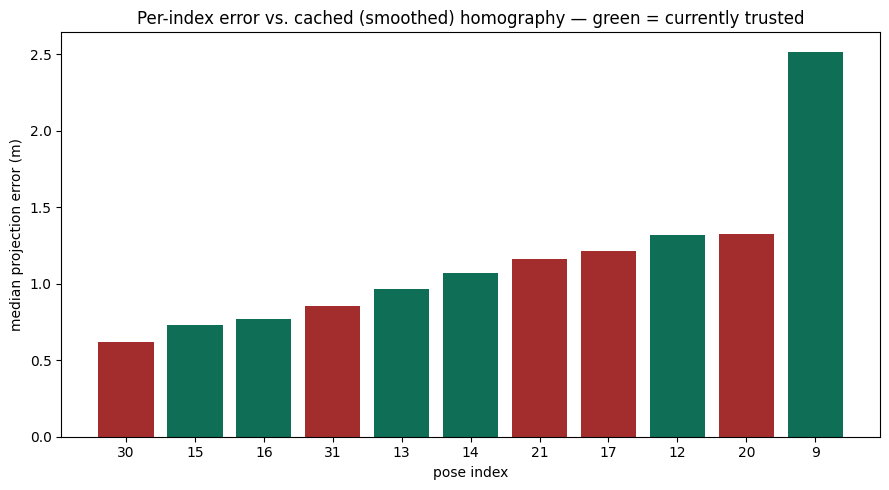

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#0F6E56" if t else "#A32D2D" for t in summary["currently_trusted"]]
ax.bar(summary.index.astype(str), summary["median_error_m"], color=colors)
ax.set_xlabel("pose index")
ax.set_ylabel("median projection error (m)")
ax.set_title("Per-index error vs. cached (smoothed) homography \u2014 green = currently trusted")
plt.tight_layout()
plt.show()


## 8. Optional — visual spot-check on a few frames

Numbers can hide a systematic issue that's obvious by eye (e.g. one index
consistently landing on the wrong side of a symmetric marking). This cell
draws every detected pose point on a handful of sampled frames, colored by
its error tier, so you can visually confirm the table above.


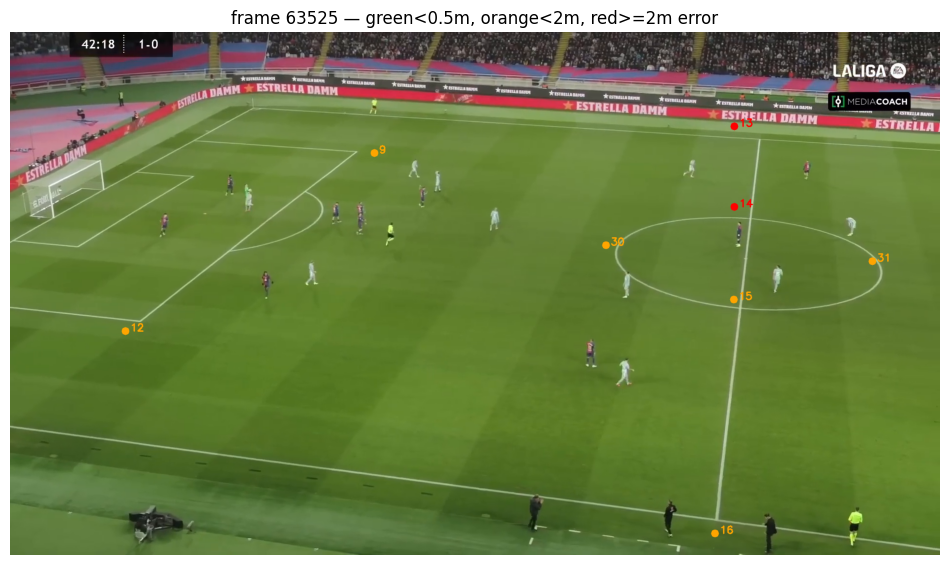

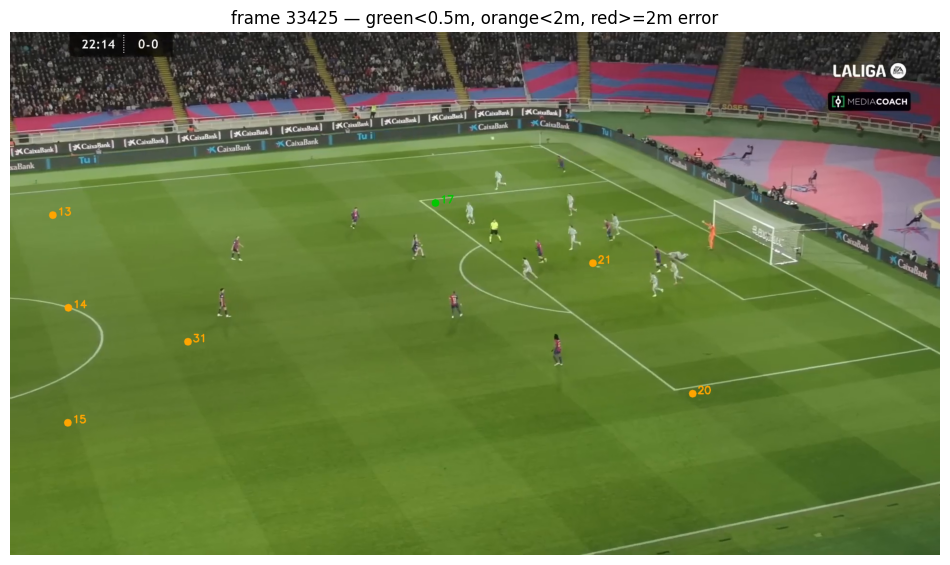

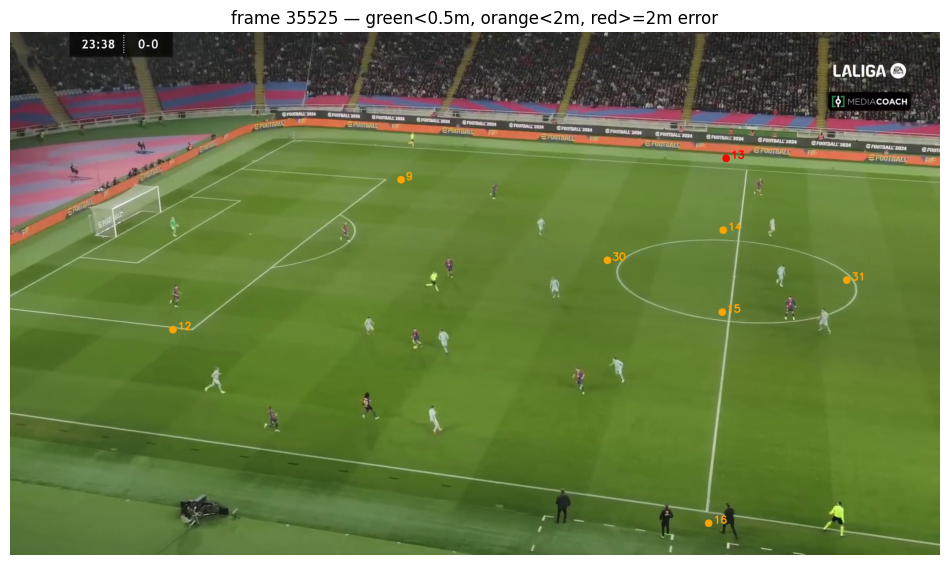

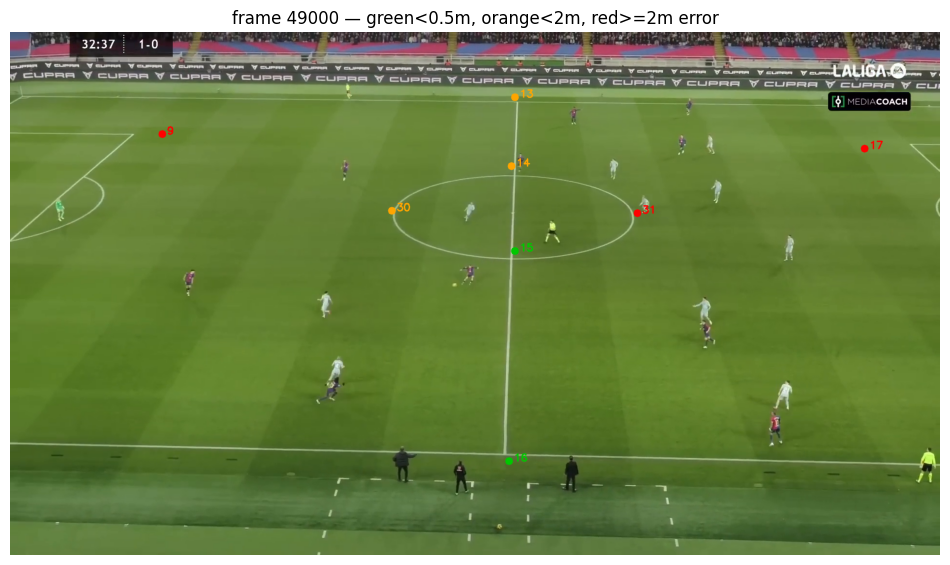

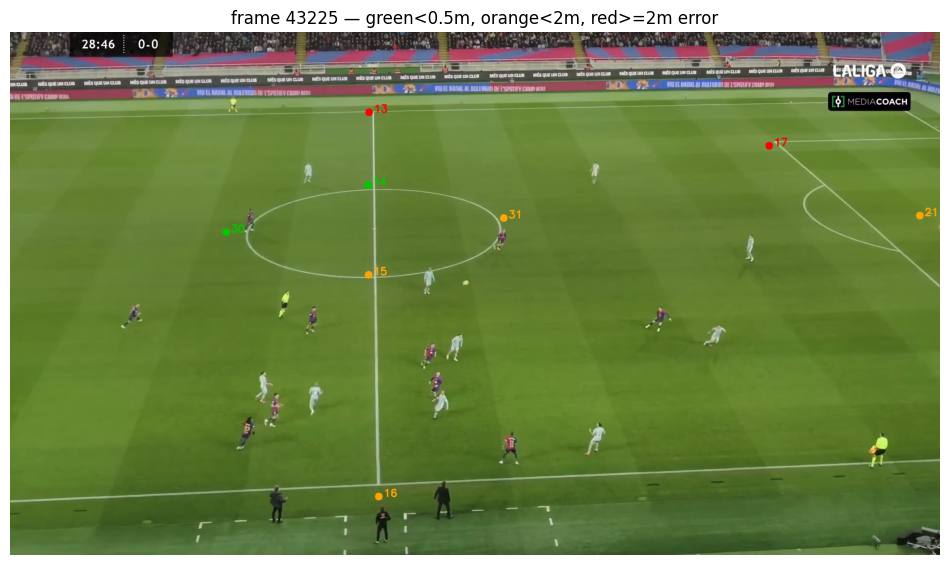

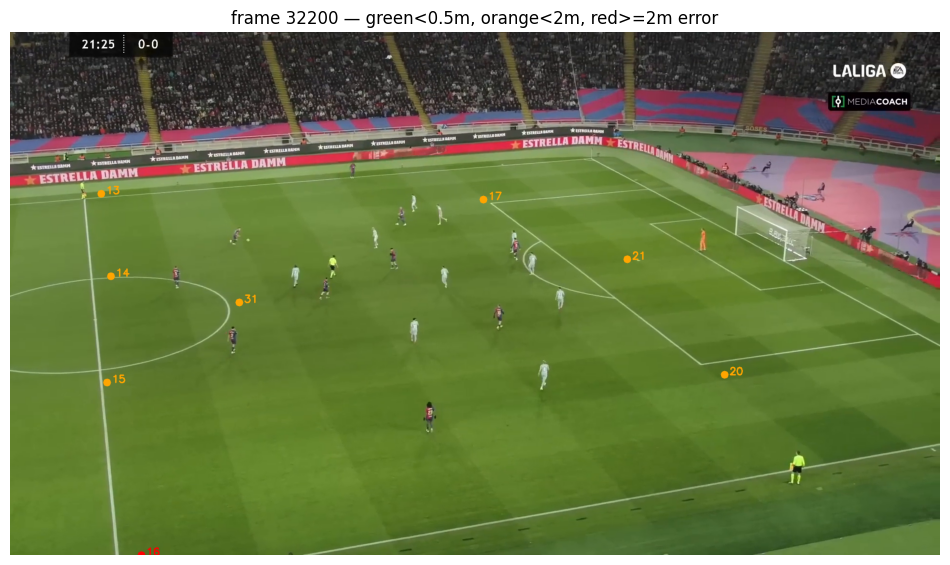

In [20]:
import random

def error_color(err_m, lo=0.5, hi=2.0):
    if err_m < lo: return (0, 200, 0)      # green: good
    if err_m < hi: return (0, 165, 255)    # orange: borderline
    return (0, 0, 255)                     # red: bad

sample_check_frames = random.sample(frame_idxs, k=min(6, len(frame_idxs)))

for idx in sample_check_frames:
    H = homography_cache[idx] if idx < len(homography_cache) else None
    if H is None:
        continue
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        continue

    pr = engine.pose_model.predict(frame, conf=cfg.conf_thresh_pose, imgsz=cfg.img_size, verbose=False)[0]
    if pr.keypoints is None or len(pr.keypoints) == 0:
        continue
    kpts = pr.keypoints.xy[0].cpu().numpy()
    confs = pr.keypoints.conf[0].cpu().numpy() if pr.keypoints.conf is not None else np.ones(len(kpts))

    vis = frame.copy()
    for pose_idx, ((x, y), c) in enumerate(zip(kpts, confs)):
        if c < cfg.conf_thresh_pose or (x == 0 and y == 0) or pose_idx not in engine.pose_keypoints_real:
            continue
        proj = cv2.perspectiveTransform(np.array([[[x, y]]], np.float32), H).reshape(2) / cfg.px_per_meter
        real = np.array(engine.pose_keypoints_real[pose_idx], np.float32)
        err_m = float(np.linalg.norm(proj - real))
        color = error_color(err_m)
        cv2.circle(vis, (int(x), int(y)), 8, color, -1)
        cv2.putText(vis, str(pose_idx), (int(x) + 10, int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"frame {idx} \u2014 green<0.5m, orange<2m, red>=2m error")
    plt.axis("off")
    plt.show()


## 8b. Targeted check — index 9 and 12 specifically

Sections 6–8 gave 9 and 12 (`left_big_rect_top_inner`, `left_big_rect_bottom_inner`)
noticeably worse scores than the rest of the currently-trusted set, despite
being assumed reliable as “left-side” points. Two things worth telling apart
before changing `TRUSTED_ANCHOR_POSE_INDICES`:

- **Imprecision** — the model detects the right general area but the exact
  pixel is a bit off (plausible: these points sit near the penalty box, where
  players cluster and partially occlude the marking).
- **Mislabeling** — the model is actually confusing the point with its
  mirror-image counterpart on the *right* side of the pitch (a left/right mix-up,
  not just noise). This would be a more serious, different kind of bug.

The next cell checks for mislabeling directly: for every detection of index 9
or 12, it compares the projected point's distance to its real target against
its distance to that target's mirror image on the other side of the pitch.


In [ ]:
MIRROR_PAIRS = {
    9:  ("left_big_rect_top_inner",    "right_big_rect_top_inner"),
    12: ("left_big_rect_bottom_inner", "right_big_rect_bottom_inner"),
}

mirror_records = []

for idx in frame_idxs:
    H = homography_cache[idx] if idx < len(homography_cache) else None
    if H is None:
        continue
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        continue

    pr = engine.pose_model.predict(frame, conf=cfg.conf_thresh_pose, imgsz=cfg.img_size, verbose=False)[0]
    if pr.keypoints is None or len(pr.keypoints) == 0:
        continue
    kpts = pr.keypoints.xy[0].cpu().numpy()
    confs = pr.keypoints.conf[0].cpu().numpy() if pr.keypoints.conf is not None else np.ones(len(kpts))

    for pose_idx, (real_key, mirror_key) in MIRROR_PAIRS.items():
        if pose_idx >= len(kpts):
            continue
        x, y = kpts[pose_idx]
        c = confs[pose_idx]
        if c < cfg.conf_thresh_pose or (x == 0 and y == 0):
            continue
        proj = cv2.perspectiveTransform(np.array([[[x, y]]], np.float32), H).reshape(2) / cfg.px_per_meter
        real_pt = np.array(engine.pitch_keypoints_real[real_key], np.float32)
        mirror_pt = np.array(engine.pitch_keypoints_real[mirror_key], np.float32)
        dist_real = float(np.linalg.norm(proj - real_pt))
        dist_mirror = float(np.linalg.norm(proj - mirror_pt))
        mirror_records.append({
            "frame": idx, "pose_idx": pose_idx, "confidence": float(c),
            "dist_to_real_m": dist_real, "dist_to_mirror_m": dist_mirror,
            "closer_to_mirror": dist_mirror < dist_real,
        })

mirror_df = pd.DataFrame(mirror_records)
mirror_summary = (
    mirror_df.groupby("pose_idx")
             .agg(n=("closer_to_mirror", "size"),
                  pct_closer_to_mirror=("closer_to_mirror", "mean"),
                  mean_dist_to_real=("dist_to_real_m", "mean"),
                  mean_dist_to_mirror=("dist_to_mirror_m", "mean"))
)
mirror_summary["pct_closer_to_mirror"] = (mirror_summary["pct_closer_to_mirror"] * 100).round(1)
mirror_summary


**How to read this table:** `pct_closer_to_mirror` is the share of detections
where the projected point actually landed *closer to the wrong (mirrored)
side* than to its real target.

- Near 0% → the errors seen in Section 6 are imprecision, not mislabeling —
  the point is just noisy, still clearly on the correct side.
- A high percentage (especially if `mean_dist_to_real` and `mean_dist_to_mirror`
  are close, i.e. it's a genuine toss-up) → points to an actual left/right
  confusion for this index, which would be worth investigating further upstream
  (e.g. in how this index's training data was labeled), not just excluding it
  from the trusted set.


### Visual spot-check, filtered to frames containing index 9 or 12

Same drawing as Section 8, but restricted to frames where 9 or 12 was actually
detected, so you don't have to hope a random sample happens to include them.


In [ ]:
target_indices = {9, 12}
frames_with_target = sorted(df[df["pose_idx"].isin(target_indices)]["frame"].unique())
print(f"{len(frames_with_target)} sampled frames contain a detection of index 9 or 12")

check_frames = random.sample(frames_with_target, k=min(6, len(frames_with_target)))

for idx in check_frames:
    H = homography_cache[idx] if idx < len(homography_cache) else None
    if H is None:
        continue
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        continue

    pr = engine.pose_model.predict(frame, conf=cfg.conf_thresh_pose, imgsz=cfg.img_size, verbose=False)[0]
    if pr.keypoints is None or len(pr.keypoints) == 0:
        continue
    kpts = pr.keypoints.xy[0].cpu().numpy()
    confs = pr.keypoints.conf[0].cpu().numpy() if pr.keypoints.conf is not None else np.ones(len(kpts))

    vis = frame.copy()
    for pose_idx, ((x, y), c) in enumerate(zip(kpts, confs)):
        if c < cfg.conf_thresh_pose or (x == 0 and y == 0) or pose_idx not in engine.pose_keypoints_real:
            continue
        proj = cv2.perspectiveTransform(np.array([[[x, y]]], np.float32), H).reshape(2) / cfg.px_per_meter
        real = np.array(engine.pose_keypoints_real[pose_idx], np.float32)
        err_m = float(np.linalg.norm(proj - real))
        # index 9/12 drawn larger + labeled with their error, everything else dimmed for context
        if pose_idx in target_indices:
            color = error_color(err_m)
            cv2.circle(vis, (int(x), int(y)), 12, color, 3)
            cv2.putText(vis, f"{pose_idx} ({err_m:.2f}m)", (int(x) + 14, int(y)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        else:
            cv2.circle(vis, (int(x), int(y)), 4, (160, 160, 160), -1)

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"frame {idx} \u2014 index 9/12 highlighted (thick ring + error), others dimmed")
    plt.axis("off")
    plt.show()


## 9. Conclusion cell — fill in after reviewing 6 and 8

In [21]:
MEASURED_TRUSTED = set(summary.sort_values("median_error_m").head(6).index)
print("Measured (data-driven) trusted set:", MEASURED_TRUSTED)
print("Current TRUSTED_ANCHOR_POSE_INDICES:", CURRENT_TRUSTED)
print("Agrees with current set:", MEASURED_TRUSTED == CURRENT_TRUSTED)


Measured (data-driven) trusted set: {13, 14, 15, 16, 30, 31}
Current TRUSTED_ANCHOR_POSE_INDICES: {16, 9, 12, 13, 14, 15}
Agrees with current set: False


In [22]:
summary  # just re-display the full table, all 11 rows, in the notebook

,n,mean_conf,mean_error_m,median_error_m,p90_error_m,currently_trusted
pose_idx,,,,,,
30,255,0.779,0.746,0.620,1.313,False
15,358,0.856,0.875,0.731,1.644,True
16,344,0.722,1.564,0.767,4.676,True
31,363,0.885,1.354,0.857,2.247,False
13,355,0.772,1.445,0.967,3.243,True
14,358,0.828,1.156,1.070,2.031,True
21,263,0.868,1.464,1.159,2.499,False
17,304,0.888,1.761,1.214,3.765,False
12,86,0.729,6.567,1.317,2.782,True
